# TV under-reach, Social over-saturation: roi_m coupled to ec_m/alpha_m

**Objective.** Every other notebook in this series (including
`tv-test-under-real-demo-data-coefficient-prior.ipynb`, the real-data
version of this same TV/Display/Social scenario) assigns each channel's
`target_roi` as an assumption *independent* of its `ec_m`/`alpha_m` --
`calibrate_channel_effects()` just rescales `beta_m`/`beta_gm` to hit
whatever `target_roi` the config states, with no functional link to the
channel's curve shape.

In reality, a channel's true performance plausibly *isn't* independent of
its curve shape: a channel that saturates faster (lower `ec_m`, often a
more narrowly-targeted audience) tends to convert better per exposure, and
a channel with richer/more memorable creative (higher `alpha_m`, better
retained) tends to persuade more per exposure too.
`SimulationConfig.roi_ec_elasticity`/`roi_alpha_elasticity`
(`data_simulator.py`) encode exactly this: `simulate_adstock_hill_params()`
adjusts each channel's `target_roi` baseline by

```
(ec_m / cross-channel geometric mean) ** roi_ec_elasticity
  * (alpha_m / cross-channel geometric mean) ** roi_alpha_elasticity
```

before `calibrate_channel_effects()` calibrates to it -- `0.0` (both
elasticities' default) is an exact no-op, reproducing every other
notebook's fully independent `target_roi` exactly.

This notebook builds the real-data-scaled TV/Display/Social scenario with
`roi_ec_elasticity=-0.3` (larger `ec_m` -> lower ROI) and
`roi_alpha_elasticity=0.3` (larger `alpha_m` -> higher ROI) -- so TV's
large audience/slow saturation now counts *against* its true ROI, partly
offset by its comparatively high retention -- and compares `default`
(uninformed `ec_m`/`alpha_m`, unaware any such coupling exists) against
`ec_alpha_only` (informed `ec_m`/`alpha_m` priors, *also* never told the
coupling exists -- just given accurate individual priors) to see whether
accurate shape priors are still enough for `roi_m` recovery once `roi_m`
is genuinely, causally tied to shape rather than an independent
assumption.

**How to read this notebook:**
- Section 1 builds the real-data-scaled, shape-coupled scenario and
  reports the resulting true `ec_m`/`alpha_m`/ceiling-fraction/`roi_m`.
- Section 2 fits `default` and `ec_alpha_only` with
  `media_prior_type='coefficient'` and compares recovery via
  `model_utils.build_comparison_table`.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_comparison_table
from model_utils import build_model_spec
from model_utils import build_real_augmented_input
from model_utils import ceiling_fraction_at_median

## 1. Real-data-scaled TV/Display/Social, with roi_m coupled to ec_m/alpha_m

Real-data sourcing as in `tv-test-under-real-demo-data-coefficient-
prior.ipynb`, with one deliberate departure: **Social is built from the real
impression-only `Channel1` series, not from `Channel3`.** Population/dates
come from the real dataset's own 20 geos and 156 weeks; TV uses the real
`Channel3` reach/frequency series and Display the real impression-only
`Channel0`.

`geo_media_rf.csv` carries reach/frequency columns for `Channel3` alone, so
the earlier notebooks in this series pointed *both* TV and Social at it. That
turns out to make the two regressors nearly redundant:
`simulate_media_from_real` normalizes each source series per geo to mean 1
and then applies per-channel scalar targets
(`current_reach_frac`/`frequency_range`), so TV's and Social's impressions
come out *exactly proportional within each geo* -- correlation 1.000 before
clipping, 0.977 after Social's `0.98` reach clip (which binds in 52.5% of
geo-weeks), and still 0.79 after adstock + Hill. Sourcing Social from
`Channel1` instead drops the post-transform TV~Social correlation to ~0.07,
so any advantage the informed `ec_m`/`alpha_m` priors show in Section 2
cannot be explained by "the shape prior is the only thing separating two
near-identical columns."

Social's story is unchanged by the swap: it remains the over-saturated
channel at ~77% of its ceiling effect, ~90% reach at ~7.5 exposures/week, and
`ec_m` shifts only 0.267 -> 0.297 (it is derived from
`target_audience_pop_frac`/`saturation_frequency` and the *median* of
per-capita impressions, none of which move materially). Under a fixed
simulator seed TV and Display come out bit-identical either way.

Two caveats on the plain-impression path, neither of which touches the fit --
`build_input_data` passes Meridian only `<channel>_impression` and
`<channel>_spend`, so reach and frequency are diagnostic columns only:
frequency is stamped on as a constant (no time texture), and the branch
applies no reach clip, so Social's *implied* reach runs above 100% of its
target audience in ~40% of geo-weeks.

Everything else -- the `target_audience_pop_frac`/`current_reach_frac`/
`frequency_range`/`target_roi` targets, plus the `roi_ec_elasticity`/
`roi_alpha_elasticity` coupling layered on top -- is as used throughout this
series.

I0000 00:00:1785265648.320346   32688 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [11.069365    1.3826793   0.29689494]


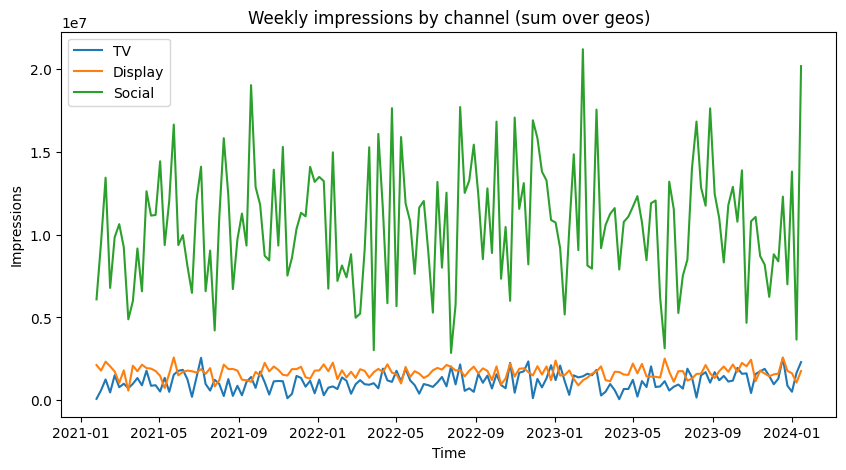

TV~Social within-geo corr (post adstock+Hill): 0.0660


In [2]:
ROI_COUPLING_CONFIG_OVERRIDES = {
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {
        'TV': (1, 2),
        'Display': (1, 5),
        'Social': (7.0, 8.0),
    },
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13,
    # Must match the real data's week count -- already the default, kept
    # explicit here since it's load-bearing for this notebook.
    'n_times': 156,
    # Match the DGP's true baseline mu_t flexibility to build_model_spec's
    # fitted knots=8 default below (otherwise mu_t defaults to one
    # independent, unsmoothed shock per week -- a large flexibility
    # mismatch against the fitted spline; see
    # tv-test-under-real-demo-data-coefficient-prior.ipynb Section 1).
    'n_knots_mu_t': 8,
    # The new part: target_roi above is now only the *baseline*, further
    # adjusted by each channel's own ec_m/alpha_m -- see this notebook's
    # header markdown.
    'roi_ec_elasticity': -0.3,
    'roi_alpha_elasticity': 0.3,
}

real_df = pd.read_csv(
    'https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_media_rf.csv'
)

config = SimulationConfig.from_dict(ROI_COUPLING_CONFIG_OVERRIDES)
sim, data, ground_truth = build_real_augmented_input(
    config,
    real_df,
    # Only TV draws on the real reach/frequency pair. Social is sourced from
    # the impression-only Channel1 rather than sharing TV's Channel3: sharing
    # it makes TV and Social exactly proportional within each geo (see this
    # section's markdown), which would leave the ec_m/alpha_m shape
    # difference as the sole signal separating them and inflate the informed
    # prior's apparent advantage in Section 2.
    rf_source_map={'TV': 'Channel3'},
    plain_source_map={'Display': 'Channel0', 'Social': 'Channel1'},
)
sim.plot_media_time_series()
plt.show()

# Sanity check the decorrelation actually held for this draw -- this is the
# whole point of the sourcing change above, so fail loudly if it regresses.
_mt = sim.media_transformed.numpy()
_i, _j = config.channel_names.index('TV'), config.channel_names.index('Social')
_tv_social_r = np.median(
    [np.corrcoef(_mt[g].T)[_i, _j] for g in range(_mt.shape[0])]
)
print(f'TV~Social within-geo corr (post adstock+Hill): {_tv_social_r:.4f}')
assert abs(_tv_social_r) < 0.3, (
    f'TV/Social collinearity regressed to {_tv_social_r:.3f} -- check the'
    ' source maps above.'
)

In [3]:
audience_national_m = sim.audience_national_m.numpy()
mean_reach_frac_m = sim.reach_count_gtm.numpy().mean(axis=(0, 1)) / (
    sim.audience_g_m.numpy().mean(axis=0)
)
mean_frequency_m = sim.frequency_gtm.numpy().mean(axis=(0, 1))
true_ec_m = sim.ec_m.numpy()
true_alpha_m = sim.alpha_m.numpy()
true_ceiling_frac = ceiling_fraction_at_median(true_ec_m)

for i, ch in enumerate(config.channel_names):
  print(
      f'{ch}: target audience ~ {audience_national_m[i] / 1e6:.1f}M, '
      f'reaching ~ {mean_reach_frac_m[i] * 100:.1f}% at frequency '
      f'~ {mean_frequency_m[i]:.1f}/week'
  )
print()
print(f'true alpha_m: {true_alpha_m}')
print(f'true ec_m (multiples of current median delivery): {true_ec_m}')
print(f'true fraction of ceiling effect captured today:   {true_ceiling_frac}')
print(
    f'true roi_m (shape-coupled, vs. independent baseline'
    f' {ROI_COUPLING_CONFIG_OVERRIDES["target_roi"]}): {ground_truth["roi_m"]}'
)

TV: target audience ~ 6.3M, reaching ~ 10.0% at frequency ~ 1.5/week
Display: target audience ~ 1.1M, reaching ~ 50.0% at frequency ~ 3.0/week
Social: target audience ~ 1.6M, reaching ~ 90.0% at frequency ~ 7.5/week

true alpha_m: [0.53567725 0.07843037 0.25244984]
true ec_m (multiples of current median delivery): [11.069365    1.3826793   0.29689494]
true fraction of ceiling effect captured today:   [0.08285441 0.41969556 0.7710725 ]
true roi_m (shape-coupled, vs. independent baseline {'TV': 8.0, 'Display': 5.0, 'Social': 3.0}): [5.911703  3.8751392 5.2381907]


## 2. default vs. ec_alpha_only, on a DGP where roi_m is truly tied to ec_m/alpha_m

Both variants use `media_prior_type='coefficient'`. Neither's prior
structure is told the DGP's `roi_ec_elasticity`/`roi_alpha_elasticity`
coupling exists -- `ec_alpha_only` is exactly the same prior used
throughout this series (independent `ec_m`/`alpha_m` priors, generic
`HalfNormal(5.0)` on `beta_m`). The question is whether accurate
*individual* shape priors are still enough for `roi_m` recovery once
`roi_m` is genuinely, causally a function of that shape -- not whether the
model needs to be told the relationship explicitly.

In [4]:
COUPLING_VARIANTS = ['default', 'ec_alpha_only']
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)

fitted_mmms = {}
for variant in COUPLING_VARIANTS:
  model_spec = build_model_spec(
      variant, sim, config, media_prior_type='coefficient'
  )
  mmm = model.Meridian(input_data=data, model_spec=model_spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS)
  fitted_mmms[variant] = mmm

build_comparison_table(fitted_mmms, config, sim, ground_truth, hdi_prob=0.9)

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


2026-07-28 14:07:57.803783: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


2026-07-28 14:11:26.563391: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,channel,param,true,default,ec_alpha_only
0,TV,alpha_m,0.536,0.551 (0.52-0.58) ✓,0.536 (0.51-0.57) ✓
1,TV,ec_m,11.069,4.750 (4.20-5.23) ✗,11.171 (9.45-13.15) ✓
2,TV,roi_m,5.912,6.579 (6.10-7.08) ✗,5.743 (5.31-6.14) ✓
3,Display,alpha_m,0.078,0.244 (0.07-0.43) ✓,0.115 (0.00-0.21) ✓
4,Display,ec_m,1.383,0.239 (0.10-0.33) ✗,1.404 (1.17-1.62) ✓
5,Display,roi_m,3.875,23.978 (3.84-37.36) ✓,4.682 (3.13-6.43) ✓
6,Social,alpha_m,0.252,0.246 (0.23-0.26) ✓,0.251 (0.23-0.27) ✓
7,Social,ec_m,0.297,0.276 (0.24-0.31) ✓,0.280 (0.25-0.31) ✓
8,Social,roi_m,5.238,5.422 (4.92-5.88) ✓,5.440 (5.03-5.78) ✓
